# Markov Chain Ensemble Using Recom

@author: taiyyoson

### Using 2018 Election Data


Markov Chain Monte Carlo(MCMC) is a computational method for sampling from
a complex probability distribution which works by building a Markov Chain - a sequence
of states(districting map) where each state is derived from previous one using a specific
proposal method. Recom is the proposal used which will talk later on. Over many
iterations, the chain converges to a stationary distribution as a representative sample
of all possible states(districting plan).
The reason to use MCMC is due to redistricting is a complex problem with
enormous number of possible districting plans. MCMC allows examiner to explore this
space efficiently, creating a representative ensemble of valid districting plans. By
analyzing this ensemble, examiner will be able to measure how a given map compares to
a large set of alternative maps.

### Procedure

Below are the steps doing MCMC:


1. Load graph and gdf from Maup’ed shp. file using geo pandas
2. Create Election list of election object of different elections such as a party’s attour-
ney general, senate, governer, or presidential election.
3. Create updaters you wish to have. E.g Cut edges, population tally, democratic wins,
etc.
4. Do initial partitions to get partition by inputting graph got from geopandas, and
then set desired assignments(”SEND” for Democrat senate, etc.) along with self
defined updaters.
5. Get ideal population from produced initial partition
6. Set proposal as partial method recom proposal with epsilon 0.1 using ideal popu-
lation got earlier.
7. Set compactness round for constraints
4
8. Finally, do Markov Chain with all result got from before and append it to 3 lists:
Cut edge, Democrat wins, and Efficiency Gap list.
9. Set steps and call enumerate(chain)
10. At last plot marginal box plots and histogram from 3 lists appended from Markov
Chain
*Note: From step 8 - 10, you need a for loop to make those do exactly 2 times which will
be 2 ensembles mentioning below

In [6]:
import pandas as pd
import geopandas as gpd
import maup
import matplotlib.pyplot as plt
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.tree import bipartition_tree
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial
from gerrychain.metrics import efficiency_gap

import time
import os

In [7]:
## making graph
sc_graph = Graph.from_file("./SC/SC.shp")
sc_gdf = gpd.read_file("./SC/SC.shp")
sc_from_gpd_graph = Graph.from_geodataframe(sc_gdf, adjacency="rook") ## creating graph from geodataframe

In [8]:
## printing graph node information fields
sc_graph.nodes[1]

{'boundary_node': False,
 'area': 8648536.552029321,
 'COUNTY': '013',
 'PCODE': '111',
 'CODE_NAME': 'Burton 1B',
 'G20PRER': 160,
 'G20PRED': 650,
 'G20USSR': 142,
 'G20USSD': 679,
 'G20USSCBLE': 7,
 'TOTPOP': 2305,
 'P0020002': 383,
 'P0020005': 591,
 'P0020006': 1203,
 'P0020007': 5,
 'P0020008': 25,
 'P0020009': 1,
 'P0020010': 19,
 'P0020011': 78,
 'VAP': 1623,
 'HVAP': 1534,
 'P0030005': 5,
 'P0030006': 22,
 'P0030007': 1,
 'P0030008': 156,
 'P0030009': 89,
 'P0030010': 84,
 'P0030011': 13,
 'BVAP': 894,
 'P0030016': 1,
 'P0030017': 0,
 'P0030018': 0,
 'P0030019': 7,
 'P0030027': 1,
 'P0030028': 0,
 'P0030029': 0,
 'P0030030': 2,
 'P0030037': 0,
 'P0030038': 0,
 'P0030039': 0,
 'P0030040': 0,
 'P0030041': 0,
 'P0030042': 0,
 'P0030048': 0,
 'P0030049': 0,
 'P0030050': 0,
 'P0030051': 0,
 'P0030052': 0,
 'P0030053': 0,
 'P0030058': 0,
 'P0030059': 0,
 'P0030060': 0,
 'P0030061': 0,
 'P0030064': 0,
 'P0030065': 0,
 'P0030066': 0,
 'P0030067': 0,
 'P0030069': 0,
 'P0030071': 0,
 'A

In [9]:
## setting up initial markov chain model

## functions for markov chain updaters
def num_cut_edges(partition):
    return len(partition['cut_edges'])

def democratic_wins(partition):
    return sum(
        1 for district in partition.parts 
        if sum(partition.graph.nodes[node]["G18ATGD"] for node in district) > 
           sum(partition.graph.nodes[node]["G18ATGR"] for node in district)
    )

elections = [
    Election("G18ATG", {"Democratic": "G18ATGD", "Republican": "G18ATGR"}),
    Election("G18SOS", {"Democratic": "G18SOSD", "Republican": "G18SOSR"}),
    Election("G18GOV", {"Democratic": "G18GOVD", "Republican": "G18GOVR"}),
    Election("G18TRE", {"Democratic": "G18TRED", "Republican": "G18TRE"})]
election_updaters = {election.name: election for election in elections}

my_updaters = {
        "cut_edges": cut_edges,
        "population": Tally("TOTPOP", alias="population"),
        "democratic_wins": democratic_wins,
        "number_cut_edges": num_cut_edges,
    }
my_updaters.update(election_updaters)

## creating initial partition
initial_partition = Partition(
    sc_graph, 
    assignment="SEND",
    updaters=my_updaters
)

## using RECOM on the random walk, need ideal population
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)
proposal = partial(recom,
                   pop_col="TOTPOP",
                   pop_target=ideal_population,
                   epsilon=0.1,
                   node_repeats=2,
                   method = partial(
                        bipartition_tree,
                        max_attempts=100,
                        allow_pair_reselection=True  # <-- This is the only change
                    )
)


## all used for building markov chain
compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2*len(initial_partition["cut_edges"])
)
pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.1)





at step 0 the time is 0.0017521381378173828
at step 50 the time is 0.3372962474822998
at step 100 the time is 1.142308235168457
at step 150 the time is 1.4452900886535645
at step 200 the time is 1.903630256652832
at step 250 the time is 2.2836050987243652
at step 300 the time is 2.7169899940490723
at step 350 the time is 3.0776729583740234
at step 400 the time is 3.5602781772613525
at step 450 the time is 3.9744880199432373
at step 500 the time is 4.307337999343872
at step 550 the time is 4.737249135971069
at step 600 the time is 5.073364973068237
at step 650 the time is 5.406212091445923
at step 700 the time is 5.775409936904907
at step 750 the time is 6.125870227813721
at step 800 the time is 6.4819371700286865
at step 850 the time is 6.886254072189331
at step 900 the time is 7.45750617980957
at step 950 the time is 7.815067291259766
at step 1000 the time is 8.239107131958008
at step 1050 the time is 8.686928272247314
at step 1100 the time is 9.950556993484497
at step 1150 the time i

100%|██████████| 20000/20000 [02:31<00:00, 131.66it/s]


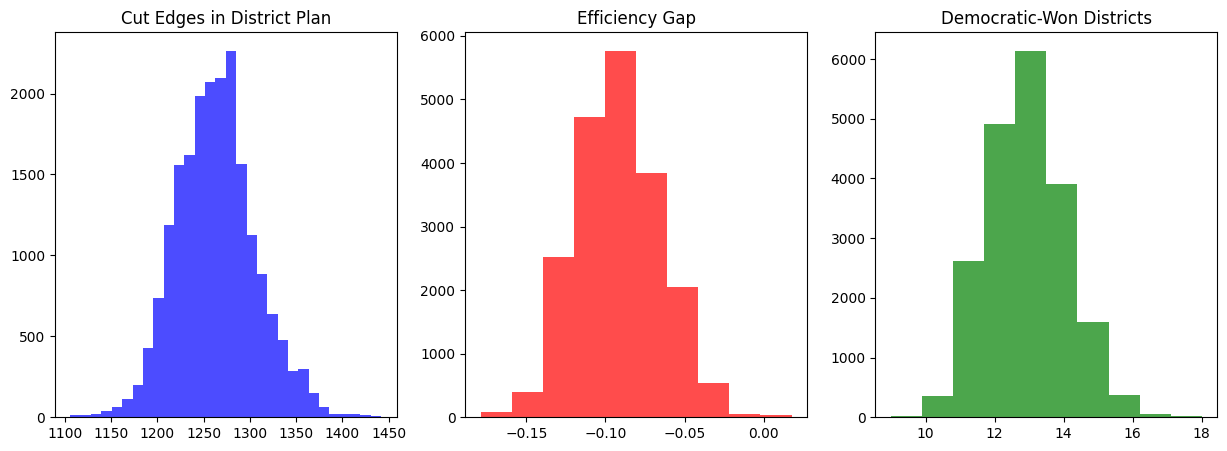

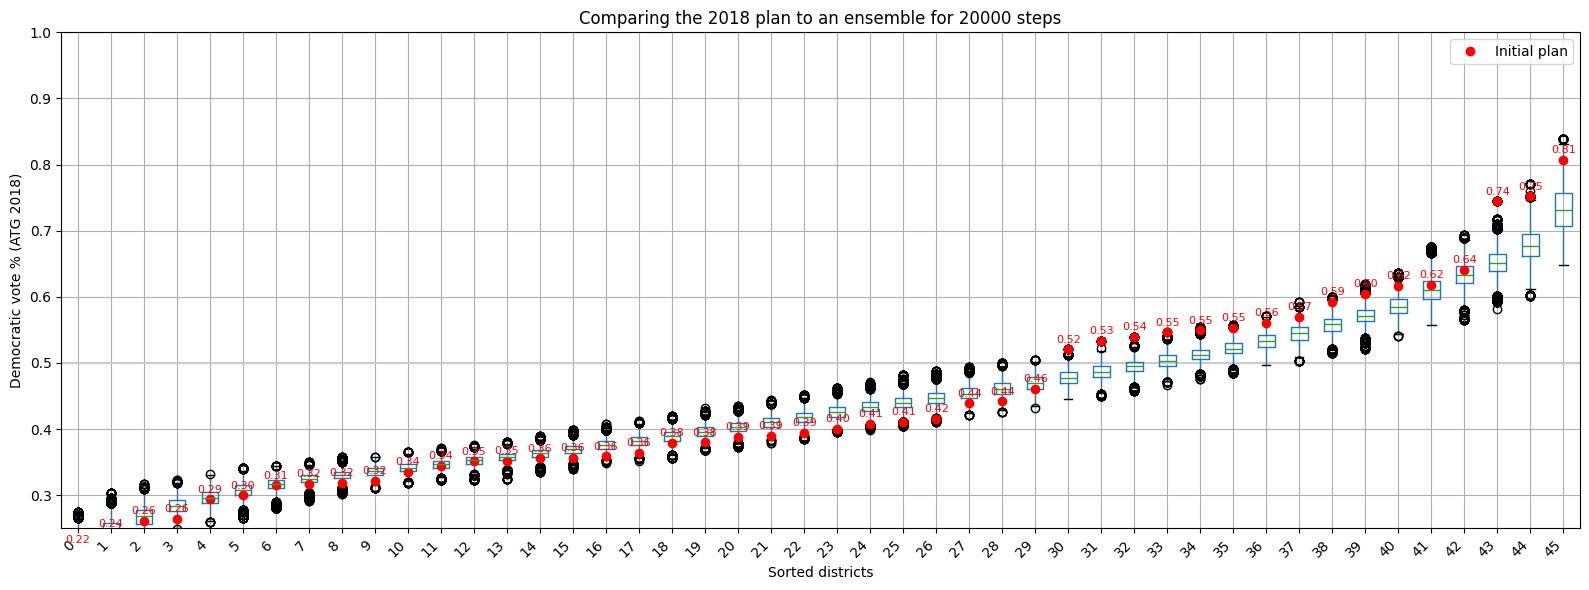

finished run 46 with 20000 steps
at step 0 the time is 0.0006270408630371094
at step 50 the time is 0.6443369388580322
at step 100 the time is 1.215620994567871
at step 150 the time is 1.8500471115112305
at step 200 the time is 2.3479089736938477
at step 250 the time is 2.668837070465088
at step 300 the time is 3.0535638332366943
at step 350 the time is 3.4136598110198975
at step 400 the time is 3.7971038818359375
at step 450 the time is 4.151654958724976
at step 500 the time is 4.50645899772644
at step 550 the time is 5.1942360401153564
at step 600 the time is 6.055813789367676
at step 650 the time is 6.419490098953247
at step 700 the time is 6.761725902557373
at step 750 the time is 7.117967128753662
at step 800 the time is 7.457881212234497
at step 850 the time is 7.8098719120025635
at step 900 the time is 8.119875192642212
at step 950 the time is 8.466255187988281
at step 1000 the time is 8.779506921768188
at step 1050 the time is 9.069994926452637
at step 1100 the time is 9.360570

100%|██████████| 40000/40000 [05:20<00:00, 124.90it/s]


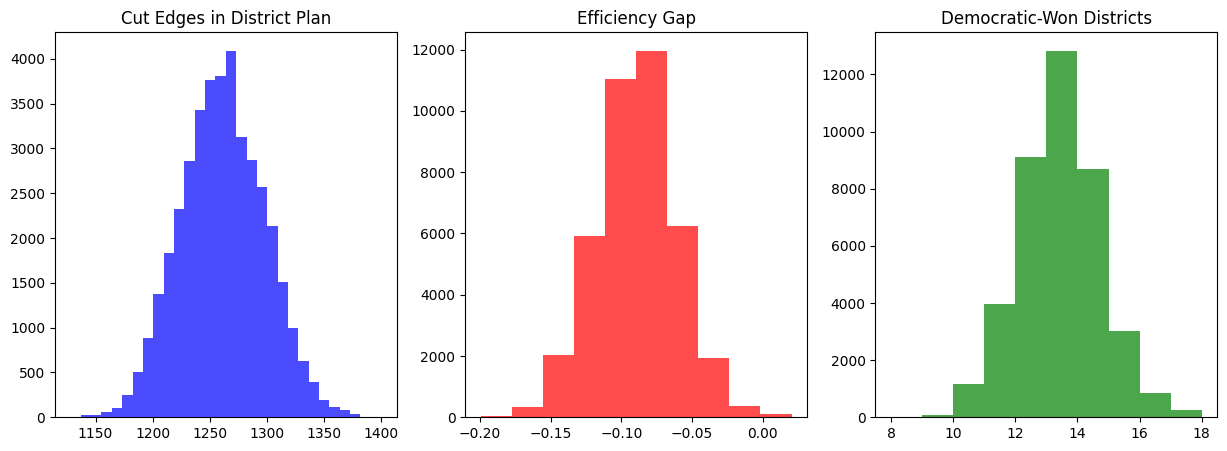

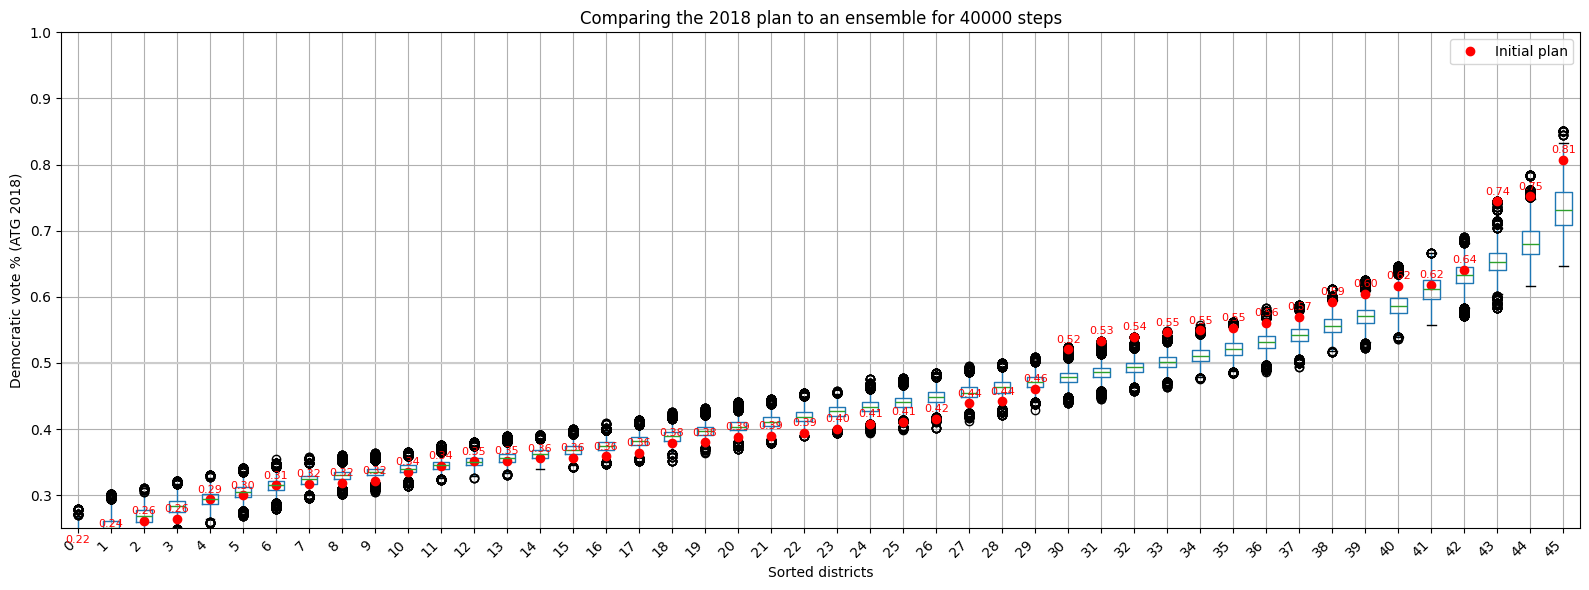

finished run 46 with 40000 steps


In [10]:
## running markov chain random walk (using recom proposal)
num_steps = 20000
for i in range(2):
    chain = MarkovChain(
        proposal=proposal,
        constraints=[compactness_bound, pop_constraint],
        accept=accept.always_accept,
        initial_state=initial_partition,
        total_steps=num_steps ## sample step count for now
    )
    
    cut_edges_list = []
    dem_wins_list = []
    EG_list = []
    start_time = time.time()
    for step, part in enumerate(chain):
        if step%50 == 0:
            print(f"at step {step} the time is {time.time() - start_time}")
        cut_edges_list.append(part["number_cut_edges"])
        dem_wins_list.append(part["G18ATG"].seats("Democratic"))
        EG_list.append(part["G18ATG"].efficiency_gap())
        
    ## plotting histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(cut_edges_list, bins=30, color='blue', alpha=0.7)
    axes[0].set_title("Cut Edges in District Plan")

    axes[1].hist(EG_list, bins=10, color='red', alpha=0.7)
    axes[1].set_title("Efficiency Gap")

    axes[2].hist(dem_wins_list, bins=10, color='green', alpha=0.7)
    axes[2].set_title("Democratic-Won Districts")
    
    ## making df for marginal box plots
    data = pd.DataFrame(
    sorted(partition["G18ATG"].percents("Democratic"))
    for partition in chain.with_progress_bar()
    )
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.axhline(0.5, color="#cccccc")

    # Boxplot of ensemble
    data.boxplot(ax=ax, positions=range(len(data.columns)))

    # Initial map
    initial_vals = data.iloc[0]
    plt.plot(initial_vals, "ro", label="Initial plan")
    for i, val in enumerate(initial_vals):
        ax.text(i, val + 0.01, f"{val:.2f}", color="red", ha='center', fontsize=8)

    # Labels & Formatting
    ax.set_title(f"Comparing the 2018 plan to an ensemble for {num_steps} steps")
    ax.set_ylabel("Democratic vote % (ATG 2018)")
    ax.set_xlabel("Sorted districts")
    ax.set_ylim(0.25, 1)
    ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'SCbox_plotATG2018_{i}.png')
    plt.show()
    

    print(f"finished run {i+1} with {num_steps} steps")
    num_steps *= 2
        
